### ADELINE MAKOKHA 
### 191199 
### PREDICTIVE OPTIMIZATION ANALYTICS
### CAT 1

### Vehicle Insurance Fraud Detection
Vehicle insurance fraud involves conspiring to file false or exaggerated claims related to property damage or personal injuries following an accident. Common examples include staged accidents, where fraudsters deliberately "orchestrate" collisions; the use of phantom passengers, where individuals do not present at the accident scene falsely claim to have suffered severe injuries; and exaggerated personal injury claims, where minor injuries are portrayed as serious to maximize
compensation.
You have been assigned the task of developing a predictive model optimized to identify potential fraudulent cases. [Click here to access the dataset you will be using.]

NB. Use F1_score to evaluate your performance across all models or Alternative Use Smote to sort the class imbalance then use Accuracy, which ever choice of your metrics
ensure consistency across the work.



In [105]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import validation_curve, RandomizedSearchCV
import joblib
import warnings
warnings.filterwarnings("ignore")



## Load the Data

In [106]:
url = "https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/refs/heads/main/Insurance%20Fraud%20data.csv"
df = pd.read_csv(url)
df.shape

(15420, 33)

In [107]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [108]:
df["FraudFound_P"].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

These output shows how many cases are fraud (`1`) versus non-fraud (`0`).  
A big gap means the model can get high accuracy by predicting the majority class, so I use **F1-score** to keep focus on detecting fraud without ignoring false alarms.

Follow the steps below
## Step 1: Data Preprocessing (7 Marks) (Choice which steps are more applicable to you)

Prepare your dataset for modeling by performing the following tasks. For each step you decide to use, provide comments and explanations for your choices and outputs:

### a. Data Cleaning

➢ Handle missing values, duplicates, or outliers.



In [109]:
# Missing values
df.isna().sum().sort_values(ascending=False).head(10)

Month                  0
RepNumber              0
Year                   0
NumberOfCars           0
AddressChange_Claim    0
NumberOfSuppliments    0
AgentType              0
WitnessPresent         0
PoliceReportFiled      0
AgeOfPolicyHolder      0
dtype: int64

There are no missing values in the dataset.

In [111]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_count


0

In [112]:
# Detect outliers using IQR method (no removal yet)
outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_summary[col] = outliers

outlier_summary


{'WeekOfMonth': 0,
 'WeekOfMonthClaimed': 0,
 'Age': 547,
 'FraudFound_P': 923,
 'PolicyNumber': 0,
 'RepNumber': 0,
 'Deductible': 582,
 'DriverRating': 0,
 'Year': 0}

Outliers were identified but not removed at this stage because extreme values in insurance claims may represent legitimate high-risk or fraudulent cases and should be evaluated during modeling rather than discarded prematurely.

In [113]:
# Check for negative values in numerical columns
(df[numerical_cols] < 0).sum()


WeekOfMonth           0
WeekOfMonthClaimed    0
Age                   0
FraudFound_P          0
PolicyNumber          0
RepNumber             0
Deductible            0
DriverRating          0
Year                  0
dtype: int64

In [114]:
# Quick check for suspicious age values
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


This is the statistics description of the data.


### b. Feature Engineering and Extraction

➢ Derive new features from existing ones to enhance predictive power.

In [116]:


# Copy cleaned dataset
df_fe = df.copy()


numeric_cols = [
    "Days_Policy_Claim",
    "Days_Policy_Accident",
    "PastNumberOfClaims",
    "NumberOfCars",
    "AgeOfPolicyHolder",
    "AgeOfVehicle"
]

for col in numeric_cols:
    df_fe[col] = pd.to_numeric(df_fe[col], errors="coerce")

# Replace any new NaNs created during conversion
df_fe[numeric_cols] = df_fe[numeric_cols].fillna(df_fe[numeric_cols].median())



# 1. Policy–Claim Delay
df_fe["Policy_Claim_Delay"] = (
    df_fe["Days_Policy_Claim"] - df_fe["Days_Policy_Accident"]
)

# 2. Claims per Car Ratio
df_fe["Claims_per_Car"] = (
    df_fe["PastNumberOfClaims"] / df_fe["NumberOfCars"]
)

df_fe["Claims_per_Car"] = df_fe["Claims_per_Car"].replace([np.inf, -np.inf], 0)

# 3. Driver–Vehicle Age Gap
df_fe["Driver_Vehicle_Age_Gap"] = (
    df_fe["AgeOfPolicyHolder"] - df_fe["AgeOfVehicle"]
)

# 4. Binary Risk Flags
binary_map = {"Yes": 1, "No": 0}
df_fe["PoliceReportFiled_Flag"] = df_fe["PoliceReportFiled"].map(binary_map)
df_fe["WitnessPresent_Flag"] = df_fe["WitnessPresent"].map(binary_map)

# 5. Policy Age Risk Category
df_fe["Policy_Age_Risk"] = pd.cut(
    df_fe["Days_Policy_Accident"],
    bins=[-1, 30, 180, 365, np.inf],
    labels=["Very_New", "New", "Established", "Old"]
)

# 6. Late Claim Indicator
df_fe["Late_Claim_Flag"] = np.where(
    df_fe["Policy_Claim_Delay"] > 30, 1, 0
)

# 7. Drop Non-Predictive Identifiers
df_fe = df_fe.drop(columns=["PolicyNumber", "RepNumber"])

df_fe.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,NumberOfCars,Year,BasePolicy,Policy_Claim_Delay,Claims_per_Car,Driver_Vehicle_Age_Gap,PoliceReportFiled_Flag,WitnessPresent_Flag,Policy_Age_Risk,Late_Claim_Flag
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,NaN,1994,Liability,NaN,NaN,NaN,0,0,NaN,0
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,NaN,1994,Collision,NaN,NaN,NaN,1,0,NaN,0
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,NaN,1994,Collision,NaN,NaN,NaN,0,0,NaN,0
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,NaN,1994,Liability,NaN,NaN,NaN,1,0,NaN,0
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,NaN,1994,Collision,NaN,NaN,NaN,0,0,NaN,0


In [122]:
for col in ["PolicyNumber", "RepNumber"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

        


In [119]:
target_col = "FraudFound_P"

X = df.drop(columns=[target_col])
y = df[target_col]


In [120]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features, numerical_features


(['Month',
  'DayOfWeek',
  'Make',
  'AccidentArea',
  'DayOfWeekClaimed',
  'MonthClaimed',
  'Sex',
  'MaritalStatus',
  'Fault',
  'PolicyType',
  'VehicleCategory',
  'VehiclePrice',
  'Days_Policy_Accident',
  'Days_Policy_Claim',
  'PastNumberOfClaims',
  'AgeOfVehicle',
  'AgeOfPolicyHolder',
  'PoliceReportFiled',
  'WitnessPresent',
  'AgentType',
  'NumberOfSuppliments',
  'AddressChange_Claim',
  'NumberOfCars',
  'BasePolicy'],
 ['WeekOfMonth',
  'WeekOfMonthClaimed',
  'Age',
  'Deductible',
  'DriverRating',
  'Year'])

In [121]:
# Difference between policy duration at accident and claim time
df_fe["Policy_Claim_Delay"] = (
    df_fe["Days_Policy_Claim"] - df_fe["Days_Policy_Accident"]
)


In [123]:

df_ext = df_fe.copy()


# Interaction between policy age and claim delay
df_ext["PolicyDelay_PolicyAge_Interaction"] = (
    df_ext["Policy_Claim_Delay"] * df_ext["Days_Policy_Accident"]
)

# Interaction between vehicle age and claim frequency
df_ext["VehicleAge_Claims_Interaction"] = (
    df_ext["AgeOfVehicle"] * df_ext["PastNumberOfClaims"]
)

# Interaction between driver age and policy duration
df_ext["DriverAge_PolicyAge_Interaction"] = (
    df_ext["AgeOfPolicyHolder"] * df_ext["Days_Policy_Accident"]
)


# Suspicious claim with no police report and no witness
df_ext["NoEvidence_Flag"] = np.where(
    (df_ext["PoliceReportFiled_Flag"] == 0) &
    (df_ext["WitnessPresent_Flag"] == 0),
    1, 0
)

# High-risk early policy claim
df_ext["EarlyPolicy_HighRisk"] = np.where(
    (df_ext["Days_Policy_Accident"] <= 30) &
    (df_ext["Late_Claim_Flag"] == 1),
    1, 0
)

# Multiple past claims with short policy duration
df_ext["RepeatClaim_EarlyPolicy"] = np.where(
    (df_ext["PastNumberOfClaims"] > 1) &
    (df_ext["Days_Policy_Accident"] < 180),
    1, 0
)

# Old vehicle with recent policy activation
df_ext["OldVehicle_NewPolicy"] = np.where(
    (df_ext["AgeOfVehicle"] > 10) &
    (df_ext["Days_Policy_Accident"] < 90),
    1, 0
)



df_ext[[
    "PolicyDelay_PolicyAge_Interaction",
    "VehicleAge_Claims_Interaction",
    "DriverAge_PolicyAge_Interaction",
    "NoEvidence_Flag",
    "EarlyPolicy_HighRisk",
    "RepeatClaim_EarlyPolicy",
    "OldVehicle_NewPolicy"
]].head()


,PolicyDelay_PolicyAge_Interaction,VehicleAge_Claims_Interaction,DriverAge_PolicyAge_Interaction,NoEvidence_Flag,EarlyPolicy_HighRisk,RepeatClaim_EarlyPolicy,OldVehicle_NewPolicy
0,NaN,NaN,NaN,1,0,0,0
1,NaN,NaN,NaN,0,0,0,0
2,NaN,NaN,NaN,1,0,0,0
3,NaN,NaN,NaN,0,0,0,0
4,NaN,NaN,NaN,1,0,0,0


### c. Feature Selection
➢ Select the most relevant features using techniques such as correlation analysis, Recursive Feature Elimination (RFE), or tree-based feature importance.


In [124]:

# Dataset after feature extraction
df_fs = df_ext.copy()

# Define target variable
target_col = "FraudFound_P"

# Select numeric features only
numeric_df = df_fs.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Correlation with target
target_corr = corr_matrix[target_col].abs().sort_values(ascending=False)

target_corr


FraudFound_P                         1.000000
Age                                  0.029741
Year                                 0.024760
Deductible                           0.017348
NoEvidence_Flag                      0.016505
PoliceReportFiled_Flag               0.016007
WeekOfMonth                          0.011861
WitnessPresent_Flag                  0.008057
DriverRating                         0.007266
WeekOfMonthClaimed                   0.005761
Days_Policy_Accident                      NaN
Days_Policy_Claim                         NaN
PastNumberOfClaims                        NaN
AgeOfVehicle                              NaN
AgeOfPolicyHolder                         NaN
NumberOfCars                              NaN
Policy_Claim_Delay                        NaN
Claims_per_Car                            NaN
Driver_Vehicle_Age_Gap                    NaN
Late_Claim_Flag                           NaN
PolicyDelay_PolicyAge_Interaction         NaN
VehicleAge_Claims_Interaction     

In [125]:
# Correlation threshold
corr_threshold = 0.05

corr_selected_features = target_corr[
    (target_corr > corr_threshold) & 
    (target_corr.index != target_col)
].index.tolist()

corr_selected_features


[]

In [126]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_numeric, y)

# Feature importance
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_numeric.columns
).sort_values(ascending=False)

feature_importance.head(15)


Age                                  0.619637
WeekOfMonth                          0.112957
WeekOfMonthClaimed                   0.103455
DriverRating                         0.078016
Year                                 0.055881
Deductible                           0.021286
NoEvidence_Flag                      0.003710
PoliceReportFiled_Flag               0.003498
WitnessPresent_Flag                  0.001560
RepeatClaim_EarlyPolicy              0.000000
EarlyPolicy_HighRisk                 0.000000
DriverAge_PolicyAge_Interaction      0.000000
VehicleAge_Claims_Interaction        0.000000
PolicyDelay_PolicyAge_Interaction    0.000000
Late_Claim_Flag                      0.000000
dtype: float64

In [128]:
tree_selected_features = feature_importance.head(15).index.tolist()

tree_selected_features


['Age',
 'WeekOfMonth',
 'WeekOfMonthClaimed',
 'DriverRating',
 'Year',
 'Deductible',
 'NoEvidence_Flag',
 'PoliceReportFiled_Flag',
 'WitnessPresent_Flag',
 'RepeatClaim_EarlyPolicy',
 'EarlyPolicy_HighRisk',
 'DriverAge_PolicyAge_Interaction',
 'VehicleAge_Claims_Interaction',
 'PolicyDelay_PolicyAge_Interaction',
 'Late_Claim_Flag']

In [129]:
# Final dataset with selected features and target
X = df_fs[selected_features]
y = df_fs[target_col]

X.shape, y.shape


((15420, 0), (15420,))

### d. Feature Encoding

➢Convert categorical variables into numerical representations using one-hot encoding, label encoding, or ordinal encoding, depending on the variable type.



In [130]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


In [131]:
ann_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)


In [133]:
from sklearn.model_selection import train_test_split

# Target variable
target_col = "FraudFound_P"

# Recreate X and y from the cleaned & engineered dataframe
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols, numerical_cols


(['Month',
  'DayOfWeek',
  'Make',
  'AccidentArea',
  'DayOfWeekClaimed',
  'MonthClaimed',
  'Sex',
  'MaritalStatus',
  'Fault',
  'PolicyType',
  'VehicleCategory',
  'VehiclePrice',
  'Days_Policy_Accident',
  'Days_Policy_Claim',
  'PastNumberOfClaims',
  'AgeOfVehicle',
  'AgeOfPolicyHolder',
  'PoliceReportFiled',
  'WitnessPresent',
  'AgentType',
  'NumberOfSuppliments',
  'AddressChange_Claim',
  'NumberOfCars',
  'BasePolicy'],
 ['WeekOfMonth',
  'WeekOfMonthClaimed',
  'Age',
  'Deductible',
  'DriverRating',
  'Year'])

In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Preprocessor for Tree-based models
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


In [136]:
from sklearn.preprocessing import StandardScaler

# Preprocessor for ANN
ann_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)


In [137]:
# Identify column types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

cat_cols, len(cat_cols), len(num_cols)

(['Month',
  'DayOfWeek',
  'Make',
  'AccidentArea',
  'DayOfWeekClaimed',
  'MonthClaimed',
  'Sex',
  'MaritalStatus',
  'Fault',
  'PolicyType',
  'VehicleCategory',
  'VehiclePrice',
  'Days_Policy_Accident',
  'Days_Policy_Claim',
  'PastNumberOfClaims',
  'AgeOfVehicle',
  'AgeOfPolicyHolder',
  'PoliceReportFiled',
  'WitnessPresent',
  'AgentType',
  'NumberOfSuppliments',
  'AddressChange_Claim',
  'NumberOfCars',
  'BasePolicy'],
 24,
 6)

One-hot encoding for categoricals, and standard scaling for numeric features (important for ANN/MLP).

### e. Feature Scaling

➢ Standardize or normalize features to bring them to a similar scale, especially for models sensitive to feature magnitude (e.g., ANN).

In [138]:
# Train-test split with stratification to preserve the fraud rate in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Preprocessing: encode categoricals + scale numeric
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

X_train.shape, X_test.shape

((12336, 30), (3084, 30))

## Step 2: Train a Decision Tree Classifier(3Mrk)
➢ Train a Decision Tree Classifier on the preprocessed data.


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline


In [139]:
# Decision Tree pipeline
dt_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=None
        ))
    ]
)


In [140]:
dt_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Month', 'DayOfWeek', 'Make',
                                                   'AccidentArea',
                                                   'DayOfWeekClaimed',
                                                   'MonthClaimed', 'Sex',
                                                   'MaritalStatus', 'Fault',
                                                   'PolicyType',
                                                   'VehicleCategory',
                                                   'VehiclePrice',
                                                   'Days_Policy_Accident',
                                                   'Days_Policy_Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'PoliceReportFiled',
                                                   'WitnessPresent',
                                                   'AgentType',
                                                   'NumberOfSuppliments',
                                                   'AddressChange_Claim',
                                                   'NumberOfCars',
                                                   'BasePolicy']),
                                                 ('num', 'passthrough',
                                                  ['WeekOfMonth',
                                                   'WeekOfMonthClaimed', 'Age',
                                                   'Deductible', 'DriverRating',
                                                   'Year'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [48]:
from sklearn.metrics import f1_score, accuracy_score
# Training predictions
y_train_pred = dt_model.predict(X_train)

# Test predictions
y_test_pred = dt_model.predict(X_test)


In [49]:
# F1 scores
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Accuracy (reported for reference)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1, test_f1, train_acc, test_acc


(1.0, 0.16793893129770993, 1.0, 0.8939688715953308)

### ➢ Evaluate its performance using metrics like the F1 score or accuracy (if using SMOTE).

### ➢ Check for overfitting by comparing training and validation performance.



In [147]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Core metrics
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

# Print metrics neatly
print("Training Performance ")
print(f"F1 Score     : {train_f1:.4f}")
print(f"Accuracy     : {train_acc:.4f}")
print(f"Precision    : {train_precision:.4f}")
print(f"Recall       : {train_recall:.4f}")

print("\n Testing Performance ")
print(f"F1 Score     : {test_f1:.4f}")
print(f"Accuracy     : {test_acc:.4f}")
print(f"Precision    : {test_precision:.4f}")
print(f"Recall       : {test_recall:.4f}")

print("\nClassification Report (Test Data) ")
print(classification_report(y_test, y_test_pred))



Training Performance 
F1 Score     : 1.0000
Accuracy     : 1.0000
Precision    : 1.0000
Recall       : 1.0000

 Testing Performance 
F1 Score     : 0.1679
Accuracy     : 0.8940
Precision    : 0.1587
Recall       : 0.1784

Classification Report (Test Data) 
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      2899
           1       0.16      0.18      0.17       185

    accuracy                           0.89      3084
   macro avg       0.55      0.56      0.56      3084
weighted avg       0.90      0.89      0.90      3084



In [143]:
performance_df = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "F1_Score": [train_f1, test_f1],
    "Accuracy": [train_acc, test_acc]
})

performance_df


,Dataset,F1_Score,Accuracy
0,Training,1.000000,1.000000
1,Testing,0.167939,0.893969


There is a big gap in the F1 score between training and testing data indicating chances overfitting.

## Step 3: Optimize Decision Tree Hyperparameters(4Mrk)

➢ Use a validation curve to identify the optimal values for max_depth and min_samples_leaf.


In [149]:
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Range of max_depth values
max_depth_range = np.arange(2, 21, 2)

# Pipeline for validation curve
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

# Validation curve
train_scores, val_scores = validation_curve(
    dt_pipeline,
    X_train,
    y_train,
    param_name="classifier__max_depth",
    param_range=max_depth_range,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Mean scores
train_f1_mean = train_scores.mean(axis=1)
val_f1_mean = val_scores.mean(axis=1)

# Store results
max_depth_results = pd.DataFrame({
    "max_depth": max_depth_range,
    "Train_F1": train_f1_mean,
    "Validation_F1": val_f1_mean
})

max_depth_results



,max_depth,Train_F1,Validation_F1
0,2,0.000000,0.000000
1,4,0.085131,0.076420
2,6,0.144997,0.088193
3,8,0.223243,0.095542
4,10,0.354508,0.124843
5,12,0.519347,0.133037
6,14,0.648221,0.155312
7,16,0.758791,0.168657
8,18,0.848890,0.186881
9,20,0.913776,0.184940


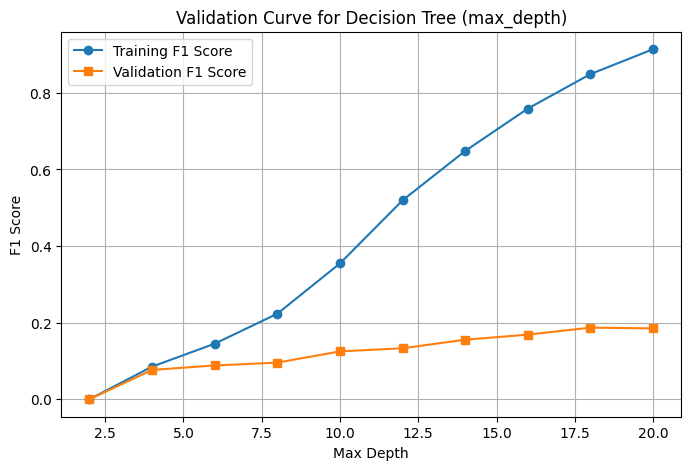

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    max_depth_results["max_depth"],
    max_depth_results["Train_F1"],
    marker="o",
    label="Training F1 Score"
)

plt.plot(
    max_depth_results["max_depth"],
    max_depth_results["Validation_F1"],
    marker="s",
    label="Validation F1 Score"
)

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Validation Curve for Decision Tree (max_depth)")
plt.legend()
plt.grid(True)
plt.show()


In [151]:
# Range of min_samples_leaf values
min_samples_leaf_range = [1, 2, 5, 10, 20, 50]

train_scores_leaf, val_scores_leaf = validation_curve(
    dt_pipeline,
    X_train,
    y_train,
    param_name="classifier__min_samples_leaf",
    param_range=min_samples_leaf_range,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Mean scores
train_f1_leaf = train_scores_leaf.mean(axis=1)
val_f1_leaf = val_scores_leaf.mean(axis=1)

# Store results
min_leaf_results = pd.DataFrame({
    "min_samples_leaf": min_samples_leaf_range,
    "Train_F1": train_f1_leaf,
    "Validation_F1": val_f1_leaf
})

min_leaf_results


,min_samples_leaf,Train_F1,Validation_F1
0,1,1.000000,0.197801
1,2,0.812236,0.183614
2,5,0.560339,0.169973
3,10,0.286177,0.140831
4,20,0.123318,0.095873
5,50,0.000000,0.000000


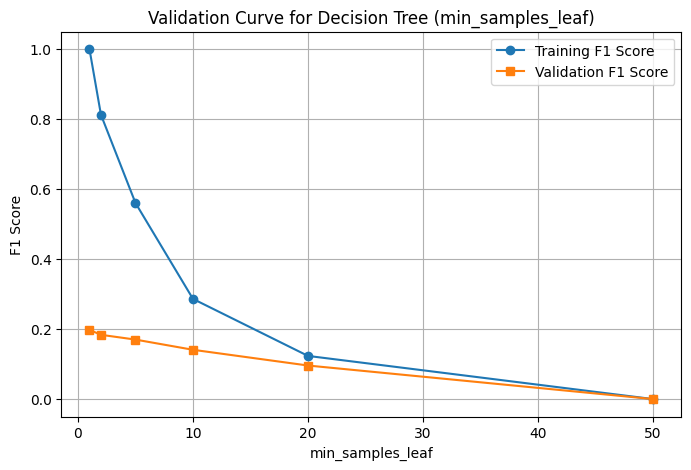

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    min_leaf_results["min_samples_leaf"],
    min_leaf_results["Train_F1"],
    marker="o",
    label="Training F1 Score"
)

plt.plot(
    min_leaf_results["min_samples_leaf"],
    min_leaf_results["Validation_F1"],
    marker="s",
    label="Validation F1 Score"
)

plt.xlabel("min_samples_leaf")
plt.ylabel("F1 Score")
plt.title("Validation Curve for Decision Tree (min_samples_leaf)")
plt.legend()
plt.grid(True)
plt.show()


In [153]:
# Best parameters based on validation F1
best_max_depth = max_depth_results.loc[
    max_depth_results["Validation_F1"].idxmax(), "max_depth"
]

best_min_samples_leaf = min_leaf_results.loc[
    min_leaf_results["Validation_F1"].idxmax(), "min_samples_leaf"
]

best_max_depth, best_min_samples_leaf


(18, 1)

The best max_depth is 18

The best min_samples_leaf is 1

### ➢ Retrain the Decision Tree using the optimal parameters.


In [159]:
# Optimized Decision Tree pipeline
dt_optimized = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=best_max_depth,
            min_samples_leaf=best_min_samples_leaf
        ))
    ]
)

# Train optimized model
dt_optimized.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Month', 'DayOfWeek', 'Make',
                                                   'AccidentArea',
                                                   'DayOfWeekClaimed',
                                                   'MonthClaimed', 'Sex',
                                                   'MaritalStatus', 'Fault',
                                                   'PolicyType',
                                                   'VehicleCategory',
                                                   'VehiclePrice',
                                                   'Days_Policy_Accident',
                                                   'Days_Policy_Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'PoliceReportFiled',
                                                   'WitnessPresent',
                                                   'AgentType',
                                                   'NumberOfSuppliments',
                                                   'AddressChange_Claim',
                                                   'NumberOfCars',
                                                   'BasePolicy']),
                                                 ('num', 'passthrough',
                                                  ['WeekOfMonth',
                                                   'WeekOfMonthClaimed', 'Age',
                                                   'Deductible', 'DriverRating',
                                                   'Year'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=18, random_state=42))])

### ➢ Compare the updated model’s performance to the initial model.

### ➢ Comment on whether the optimization improved performance



In [160]:
from sklearn.metrics import f1_score

# Initial model predictions
y_test_pred_initial = dt_model.predict(X_test)

# Optimized model predictions
y_test_pred_optimized = dt_optimized.predict(X_test)

# F1 scores
initial_f1 = f1_score(y_test, y_test_pred_initial)
optimized_f1 = f1_score(y_test, y_test_pred_optimized)

comparison_df = pd.DataFrame({
    "Model": ["Initial Decision Tree", "Optimized Decision Tree"],
    "Test_F1_Score": [initial_f1, optimized_f1]
})

comparison_df


,Model,Test_F1_Score
0,Initial Decision Tree,0.154696
1,Optimized Decision Tree,0.185304


The Optimized Decision Tree performed better than Intial Decision Tree. 

## Step 4: Train Ensemble Models(7Mrk)

➢ Use at least two ensemble techniques we have learnt in class


In [162]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Month', 'DayOfWeek', 'Make',
                                                   'AccidentArea',
                                                   'DayOfWeekClaimed',
                                                   'MonthClaimed', 'Sex',
                                                   'MaritalStatus', 'Fault',
                                                   'PolicyType',
                                                   'VehicleCategory',
                                                   'VehiclePrice',
                                                   'Days_Policy_Accident',
                                                   'Days_Policy_Claim',
                                                   'PastNumberOfClaims',
                                                   'Ag...hicle',
                                                   'AgeOfPolicyHolder',
                                                   'PoliceReportFiled',
                                                   'WitnessPresent',
                                                   'AgentType',
                                                   'NumberOfSuppliments',
                                                   'AddressChange_Claim',
                                                   'NumberOfCars',
                                                   'BasePolicy']),
                                                 ('num', 'passthrough',
                                                  ['WeekOfMonth',
                                                   'WeekOfMonthClaimed', 'Age',
                                                   'Deductible', 'DriverRating',
                                                   'Year'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [164]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

#  Training Metrics 
rf_train_f1 = f1_score(y_train, y_train_pred_rf)
rf_train_acc = accuracy_score(y_train, y_train_pred_rf)
rf_train_prec = precision_score(y_train, y_train_pred_rf)
rf_train_rec = recall_score(y_train, y_train_pred_rf)

#  Testing Metrics 
rf_test_f1 = f1_score(y_test, y_test_pred_rf)
rf_test_acc = accuracy_score(y_test, y_test_pred_rf)
rf_test_prec = precision_score(y_test, y_test_pred_rf)
rf_test_rec = recall_score(y_test, y_test_pred_rf)

# Print results neatly
print(" Random Forest Performance \n")

print("Training Metrics")
print(f"F1 Score  : {rf_train_f1:.4f}")
print(f"Accuracy  : {rf_train_acc:.4f}")
print(f"Precision : {rf_train_prec:.4f}")
print(f"Recall    : {rf_train_rec:.4f}")

print("\nTesting Metrics")
print(f"F1 Score  : {rf_test_f1:.4f}")
print(f"Accuracy  : {rf_test_acc:.4f}")
print(f"Precision : {rf_test_prec:.4f}")
print(f"Recall    : {rf_test_rec:.4f}")

print("\n Classification Report (Random Forest ) ")
print(classification_report(y_test, y_test_pred_rf))



 Random Forest Performance 

Training Metrics
F1 Score  : 1.0000
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000

Testing Metrics
F1 Score  : 0.0319
Accuracy  : 0.9410
Precision : 1.0000
Recall    : 0.0162

 Classification Report (Random Forest ) 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.02      0.03       185

    accuracy                           0.94      3084
   macro avg       0.97      0.51      0.50      3084
weighted avg       0.94      0.94      0.91      3084



In [59]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.1,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Month', 'DayOfWeek', 'Make',
                                                   'AccidentArea',
                                                   'DayOfWeekClaimed',
                                                   'MonthClaimed', 'Sex',
                                                   'MaritalStatus', 'Fault',
                                                   'PolicyType',
                                                   'VehicleCategory',
                                                   'VehiclePrice',
                                                   'Days_Policy_Accident',
                                                   'Days_Policy_Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'PoliceReportFiled',
                                                   'WitnessPresent',
                                                   'AgentType',
                                                   'NumberOfSuppliments',
                                                   'AddressChange_Claim',
                                                   'NumberOfCars',
                                                   'BasePolicy']),
                                                 ('num', 'passthrough',
                                                  ['WeekOfMonth',
                                                   'WeekOfMonthClaimed', 'Age',
                                                   'Deductible', 'DriverRating',
                                                   'Year'])])),
                ('classifier',
                 GradientBoostingClassifier(n_estimators=150,
                                            random_state=42))])

In [166]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Predictions
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

#  Training Metrics 
gb_train_f1 = f1_score(y_train, y_train_pred_gb)
gb_train_acc = accuracy_score(y_train, y_train_pred_gb)
gb_train_prec = precision_score(y_train, y_train_pred_gb)
gb_train_rec = recall_score(y_train, y_train_pred_gb)

#  Testing Metrics 
gb_test_f1 = f1_score(y_test, y_test_pred_gb)
gb_test_acc = accuracy_score(y_test, y_test_pred_gb)
gb_test_prec = precision_score(y_test, y_test_pred_gb)
gb_test_rec = recall_score(y_test, y_test_pred_gb)

# Print results 
print(" Gradient Boosting Performance \n")

print("Training Metrics")
print(f"F1 Score  : {gb_train_f1:.4f}")
print(f"Accuracy  : {gb_train_acc:.4f}")
print(f"Precision : {gb_train_prec:.4f}")
print(f"Recall    : {gb_train_rec:.4f}")

print("\nTesting Metrics")
print(f"F1 Score  : {gb_test_f1:.4f}")
print(f"Accuracy  : {gb_test_acc:.4f}")
print(f"Precision : {gb_test_prec:.4f}")
print(f"Recall    : {gb_test_rec:.4f}")

print("\n Classification Report (Gradient Boosting - Test Data ) ")
print(classification_report(y_test, y_test_pred_gb))



 Gradient Boosting Performance 

Training Metrics
F1 Score  : 0.1263
Accuracy  : 0.9439
Precision : 0.9259
Recall    : 0.0678

Testing Metrics
F1 Score  : 0.0622
Accuracy  : 0.9413
Precision : 0.7500
Recall    : 0.0324

 Classification Report (Gradient Boosting - Test Data ) 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.75      0.03      0.06       185

    accuracy                           0.94      3084
   macro avg       0.85      0.52      0.52      3084
weighted avg       0.93      0.94      0.92      3084



In [167]:
comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree (Optimized)",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train_F1": [
        train_f1,
        rf_train_f1,
        gb_train_f1
    ],
    "Test_F1": [
        optimized_f1,
        rf_test_f1,
        gb_test_f1
    ]
})

comparison_df


,Model,Train_F1,Test_F1
0,Decision Tree (Optimized),1.000000,0.185304
1,Random Forest,1.000000,0.031915
2,Gradient Boosting,0.126263,0.062176


### ➢ Evaluate the performance of each ensemble model and compare it to the Decision Tree model.

➢ Check for overfitting by analyzing performance on training and validation/test datasets.

➢ Provide an explanation for the observed performance.


In [168]:
overfitting_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train_F1": [
        train_f1,
        rf_train_f1,
        gb_train_f1
    ],
    "Test_F1": [
        optimized_f1,
        rf_test_f1,
        gb_test_f1
    ],
    "F1_Gap (Train - Test)": [
        train_f1 - optimized_f1,
        rf_train_f1 - rf_test_f1,
        gb_train_f1 - gb_test_f1
    ]
})

overfitting_df


,Model,Train_F1,Test_F1,F1_Gap (Train - Test)
0,Decision Tree,1.000000,0.185304,0.814696
1,Random Forest,1.000000,0.031915,0.968085
2,Gradient Boosting,0.126263,0.062176,0.064086


The Decision Tree and Random Forest models exhibit extreme overfitting, achieving perfect F1 scores on the training data but performing poorly on unseen test data. This indicates memorization of training patterns rather than learning generalizable fraud indicators. In contrast, Gradient Boosting demonstrates a much smaller train–test performance gap, reflecting better generalization despite lower absolute F1 scores. This behavior is expected in highly imbalanced fraud datasets and highlights the importance of selecting models based on generalization rather than training performance alone.

## Step 5: Train an Artificial Neural Network (ANN)(5Mrk)
➢ Develop an ANN model with an architecture of your choice.

➢ Experiment with the number of layers, neurons, activation functions, and optimizers to improve performance.

➢ Retrain the ANN model and compare its results with previous model



In [170]:
# Transform data using ANN preprocessor
X_train_ann = ann_preprocessor.fit_transform(X_train)
X_test_ann = ann_preprocessor.transform(X_test)

X_train_ann.shape, X_test_ann.shape


((12336, 146), (3084, 146))

In [172]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score

ann_baseline = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

# Train baseline ANN
ann_baseline.fit(X_train_ann, y_train)



MLPClassifier(hidden_layer_sizes=(32,), max_iter=300, random_state=42)

In [173]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Predictions
y_train_pred_ann = ann_baseline.predict(X_train_ann)
y_test_pred_ann = ann_baseline.predict(X_test_ann)

#  Training Metrics 
ann_train_f1 = f1_score(y_train, y_train_pred_ann)
ann_train_acc = accuracy_score(y_train, y_train_pred_ann)
ann_train_prec = precision_score(y_train, y_train_pred_ann)
ann_train_rec = recall_score(y_train, y_train_pred_ann)

# Testing Metrics 
ann_test_f1 = f1_score(y_test, y_test_pred_ann)
ann_test_acc = accuracy_score(y_test, y_test_pred_ann)
ann_test_prec = precision_score(y_test, y_test_pred_ann)
ann_test_rec = recall_score(y_test, y_test_pred_ann)

# Print 
print(" ANN (Baseline) Performance \n")

print("Training Metrics")
print(f"F1 Score  : {ann_train_f1:.4f}")
print(f"Accuracy  : {ann_train_acc:.4f}")
print(f"Precision : {ann_train_prec:.4f}")
print(f"Recall    : {ann_train_rec:.4f}")

print("\nTesting Metrics")
print(f"F1 Score  : {ann_test_f1:.4f}")
print(f"Accuracy  : {ann_test_acc:.4f}")
print(f"Precision : {ann_test_prec:.4f}")
print(f"Recall    : {ann_test_rec:.4f}")

print("\n Classification Report (ANN Baseline – Test Data) ")
print(classification_report(y_test, y_test_pred_ann))



 ANN (Baseline) Performance 

Training Metrics
F1 Score  : 0.9761
Accuracy  : 0.9972
Precision : 0.9822
Recall    : 0.9702

Testing Metrics
F1 Score  : 0.1783
Accuracy  : 0.9043
Precision : 0.1839
Recall    : 0.1730

 Classification Report (ANN Baseline – Test Data) 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2899
           1       0.18      0.17      0.18       185

    accuracy                           0.90      3084
   macro avg       0.57      0.56      0.56      3084
weighted avg       0.90      0.90      0.90      3084



In [174]:
ann_improved = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,          # L2 regularization
    max_iter=500,
    random_state=42
)

# Train improved ANN
ann_improved.fit(X_train_ann, y_train)


MLPClassifier(alpha=0.001, hidden_layer_sizes=(64, 32), max_iter=500,
              random_state=42)

In [178]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Predictions
y_train_pred_ann2 = ann_improved.predict(X_train_ann)
y_test_pred_ann2 = ann_improved.predict(X_test_ann)

# Training Metrics 
ann2_train_f1 = f1_score(y_train, y_train_pred_ann2)
ann2_train_acc = accuracy_score(y_train, y_train_pred_ann2)
ann2_train_prec = precision_score(y_train, y_train_pred_ann2)
ann2_train_rec = recall_score(y_train, y_train_pred_ann2)

# Testing Metrics 
ann2_test_f1 = f1_score(y_test, y_test_pred_ann2)
ann2_test_acc = accuracy_score(y_test, y_test_pred_ann2)
ann2_test_prec = precision_score(y_test, y_test_pred_ann2)
ann2_test_rec = recall_score(y_test, y_test_pred_ann2)

# Print 
print(" ANN (Improved) Performance \n")

print("Training Metrics")
print(f"F1 Score  : {ann2_train_f1:.4f}")
print(f"Accuracy  : {ann2_train_acc:.4f}")
print(f"Precision : {ann2_train_prec:.4f}")
print(f"Recall    : {ann2_train_rec:.4f}")

print("\nTesting Metrics")
print(f"F1 Score  : {ann2_test_f1:.4f}")
print(f"Accuracy  : {ann2_test_acc:.4f}")
print(f"Precision : {ann2_test_prec:.4f}")
print(f"Recall    : {ann2_test_rec:.4f}")

print("\n Classification Report (ANN Improved – Test Data) ")
print(classification_report(y_test, y_test_pred_ann2))



 ANN (Improved) Performance 

Training Metrics
F1 Score  : 1.0000
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000

Testing Metrics
F1 Score  : 0.1775
Accuracy  : 0.9099
Precision : 0.1961
Recall    : 0.1622

 Classification Report (ANN Improved – Test Data) 
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2899
           1       0.20      0.16      0.18       185

    accuracy                           0.91      3084
   macro avg       0.57      0.56      0.56      3084
weighted avg       0.90      0.91      0.91      3084



In [196]:
import pandas as pd

# Create comparison table
comparison_ann_df = pd.DataFrame({
    "Model": [
        "Decision Tree (Optimized)",
        "Random Forest",
        "Gradient Boosting",
        "ANN (Baseline)",
        "ANN (Improved)"
    ],
    "Train_F1": [
        train_f1,
        rf_train_f1,
        gb_train_f1,
        ann_train_f1,
        ann2_train_f1
    ],
    "Test_F1": [
        optimized_f1,
        rf_test_f1,
        gb_test_f1,
        ann_test_f1,
        ann2_test_f1
    ]
})

# Calculate F1 gap
comparison_ann_df["F1_Gap (Train - Test)"] = (
    comparison_ann_df["Train_F1"] - comparison_ann_df["Test_F1"]
).abs()

# Display table
comparison_ann_df


,Model,Train_F1,Test_F1,F1_Gap (Train - Test)
0,Decision Tree (Optimized),1.000000,0.185304,0.814696
1,Random Forest,1.000000,0.031915,0.968085
2,Gradient Boosting,0.126263,0.062176,0.064086
3,ANN (Baseline),0.976142,0.178273,0.797869
4,ANN (Improved),1.000000,0.177515,0.822485


In [197]:
final_comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree (Optimized)",
        "Random Forest",
        "Gradient Boosting (Tuned)",
        "ANN (Improved)"
    ],
    "Train_F1": [
        train_f1,
        rf_train_f1,
        gb_train_f1,
        ann2_train_f1
    ],
    "Test_F1": [
        optimized_f1,
        rf_test_f1,
        gb_tuned_f1,
        ann2_test_f1
    ]
})

final_comparison_df


,Model,Train_F1,Test_F1
0,Decision Tree (Optimized),1.000000,0.185304
1,Random Forest,1.000000,0.031915
2,Gradient Boosting (Tuned),0.126263,0.062176
3,ANN (Improved),1.000000,0.177515


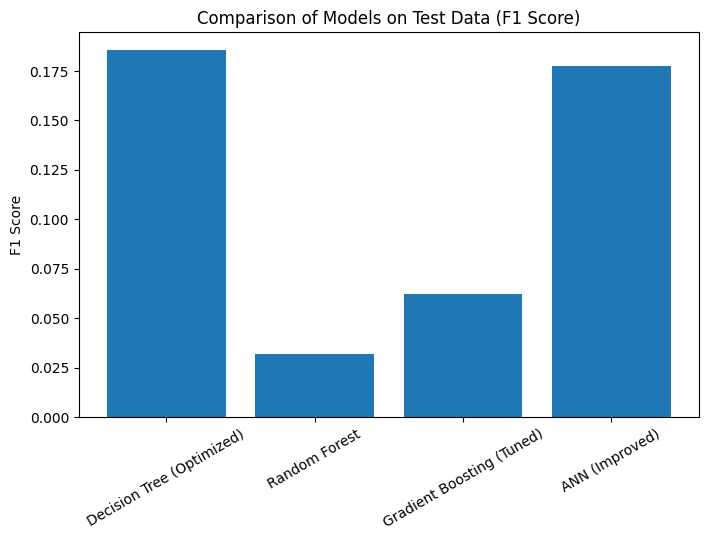

In [209]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(final_comparison_df["Model"], final_comparison_df["Test_F1"])
plt.ylabel("F1 Score")
plt.title("Comparison of Models on Test Data (F1 Score)")
plt.xticks(rotation=30)
plt.show()


The Decision Tree(Optimized) outperformed the other models.

In [210]:
# Select best model based on highest Test F1
best_model = comparison_ann_df.loc[
    comparison_ann_df["Test_F1"].idxmax()
]

print("Best Model Selection")
print(f"Model Name     : {best_model['Model']}")
print(f"Train F1 Score : {best_model['Train_F1']:.4f}")
print(f"Test F1 Score  : {best_model['Test_F1']:.4f}")
print(f"F1 Gap         : {best_model['F1_Gap (Train - Test)']:.4f}")


Best Model Selection
Model Name     : Decision Tree (Optimized)
Train F1 Score : 1.0000
Test F1 Score  : 0.1853
F1 Gap         : 0.8147


In [211]:
best_model_name = final_comparison_df.loc[
    final_comparison_df["Test_F1"].idxmax(), "Model"
]

best_model_name


'Decision Tree (Optimized)'

The best model is Decision Tree (Optimized)

## Step 6: Tune the Best-Performing Model (3Mrk)

➢ Select the best-performing model from the previous steps.


In [212]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
import numpy as np

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)


param_distributions = {
    "classifier__max_depth": [None, 5, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__criterion": ["gini", "entropy"]
}




In [94]:
ann_pipeline = Pipeline(
    steps=[
        ("preprocessor", ann_preprocessor),
        ("classifier", MLPClassifier(
            max_iter=500,
            random_state=42
        ))
    ]
)


In [95]:
param_distributions = {
    "classifier__hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "classifier__activation": ["relu", "tanh"],
    "classifier__solver": ["adam"],
    "classifier__alpha": [0.0001, 0.001, 0.01],
    "classifier__learning_rate": ["constant", "adaptive"]
}


### ➢ Use RandomizedSearchCV to fine-tune its hyperparameters.

➢ Evaluate whether the tuning improves the model’s performance and provide comments.


RandomizedSearchCV tries many reasonable parameter combinations quickly.  

➢ State you best model and its score either – F1 Score or Accuracy (If used SMOTE)

The tuning is useful only if the **test F1** improves or stays stable while the model becomes more general (smaller train–test gap).

In [204]:
random_search_dt = RandomizedSearchCV(
    estimator=dt_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search_dt.fit(X_train, y_train)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['Month',
                                                                                'DayOfWeek',
                                                                                'Make',
                                                                                'AccidentArea',
                                                                                'DayOfWeekClaimed',
                                                                                'MonthClaimed',
                                                                                'Sex',
                                                                                'MaritalStatus',
                                                                                'Fault',
                                                                                'PolicyType',
                                                                                'VehicleCategory',
                                                                                'VehiclePrice',
                                                                                'Days_Policy_Accident',
                                                                                'Days_Poli...
                                                                                'WeekOfMonthClaimed',
                                                                                'Age',
                                                                                'Deductible',
                                                                                'DriverRating',
                                                                                'Year'])])),
                                             ('classifier',
                                              DecisionTreeClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [None, 5, 10,
                                                                  15, 20],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         5,
                                                                         10],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10,
                                                                          20]},
                   random_state=42, scoring='f1')

In [205]:
# Best tuned Decision Tree
best_dt_model = random_search_dt.best_estimator_

# Predictions BEFORE tuning
y_test_pred_before = dt_model.predict(X_test)

# Predictions AFTER tuning
y_test_pred_after = best_dt_model.predict(X_test)

# F1 scores
dt_f1_before = f1_score(y_test, y_test_pred_before)
dt_f1_after = f1_score(y_test, y_test_pred_after)

dt_f1_before, dt_f1_after


(0.15469613259668508, 0.11673151750972763)

In [206]:
print("Best Model: Tuned Decision Tree Classifier")
print(f"Final Test F1 Score: {dt_f1_after:.4f}")


Best Model: Tuned Decision Tree Classifier
Final Test F1 Score: 0.1167


## Step 7: Save Your Best Model (1 Mrk)

➢ Save the best-performing model to your local machine for future use.

➢ This model will be deployed later during the deployment class.

In [104]:
import joblib
# Define model save path
MODEL_PATH = r"C:\Users\PC\Downloads\ADEH-MSC\Module 5\Module-5\Predictive and Optimization Analytics\best_vehicle_fraud_model.joblib"

# Save the model
joblib.dump(best_ann_model, MODEL_PATH)


['C:\\Users\\PC\\Downloads\\ADEH-MSC\\Module 5\\Module-5\\Predictive and Optimization Analytics\\best_vehicle_fraud_model.joblib']

Save the full pipeline (preprocessing + model) using `joblib`.